<a href="https://colab.research.google.com/github/allaalmouiz/MachineTranslation_nlp/blob/main/MachineTranslation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Translation Challange - Module 5 | Part 2
Submitted by: **`Alaa Almouiz F. Moh.`**

ID Number: **`S2026_176`**

Track: **Machine Learning**

For: **ZAKA ©**

## **1- Problem Statement (Objective)**
Using  Neural Networks to build a model that translates text from **English to French**.

The model receives an English sentence as input and generates the corresponding French sentence as output. This is known as Neural Machine Translation (NMT).

### **Challenges:**
* Word **order** differs across languages.
* One word may **translate to several words**.
* **Context** affects meaning.
* Sentence **lengths vary**.

### **Expected model behaviour**
* The model may perform well on **short common sentences** - struggle with long sentences or rare words.
* The **vocabulary size may affec**t translation quality.

## **2. Loading the dataset**

In [1]:
!pip install -q nltk seaborn

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import string
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report

In [3]:
# Loading the dataset from GitHub

!git clone https://github.com/allaalmouiz/MachineTranslation_nlp.git
%cd MachineTranslation_nlp


Cloning into 'MachineTranslation_nlp'...
remote: Enumerating objects: 18, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 18 (delta 3), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (18/18), 2.37 MiB | 3.63 MiB/s, done.
Resolving deltas: 100% (3/3), done.
/content/MachineTranslation_nlp


In [4]:
# Having the English and French datset
en = pd.read_csv("en.csv", header=None, names=["english"])
fr = pd.read_csv("fr.csv", header=None, names=["french"])

In [5]:
# Checking the first 5 samples of the English datset
en.head()

,english
0,"new jersey is sometimes quiet during autumn , ..."
1,the united states is usually chilly during jul...
2,"california is usually quiet during march , and..."
3,the united states is sometimes mild during jun...
4,"your least liked fruit is the grape , but my l..."


In [6]:
# Checking the first 5 samples of the English datset
fr.head()

,french
0,new jersey est parfois calme pendant l' automn...
1,les états-unis est généralement froid en juill...
2,"california est généralement calme en mars , et..."
3,"les états-unis est parfois légère en juin , et..."
4,"votre moins aimé fruit est le raisin , mais mo..."


In [7]:
# Printing the first english sentence and it's translation in french
print(f"English: {en['english'][0]}\nFrench: {fr['french'][0]}")
print("")
print(f"shape of the English datsets is: {en.shape}")
print(f"shape of the French datsets is: {fr.shape}")

English: new jersey is sometimes quiet during autumn , and it is snowy in april .
French: new jersey est parfois calme pendant l' automne , et il est neigeux en avril .

shape of the English datsets is: (137860, 1)
shape of the French datsets is: (137860, 1)


Now since we confirmed that they are in the same size, we can concatinate.

In [8]:
# Concatinate in one dataset and save into "en_fr_dataset.csv"
df = pd.concat([en, fr], axis=1)

df.to_csv("en_fr_dataset.csv", index=False)

In [9]:
df.head(1)


,english,french
0,"new jersey is sometimes quiet during autumn , ...",new jersey est parfois calme pendant l' automn...


In [10]:
# Checking null values

df.isnull().sum()

,0
english,0
french,0


## **3- Exploring and Processing the text dataset - NLP Processing**

In [11]:
# Length of sentences in English and French datasets

df["en_len"] = df["english"].apply(lambda x: len(x.split()))
df["fr_len"] = df["french"].apply(lambda x: len(x.split()))

print(df[["en_len","fr_len"]].describe())

              en_len         fr_len
count  137860.000000  137860.000000
mean       13.225374      14.226716
std         3.191240       3.016955
min         3.000000       3.000000
25%         9.000000      12.000000
50%        15.000000      15.000000
75%        15.000000      16.000000
max        17.000000      23.000000


In [12]:
print(f"The maximum sentence length for english is {df['en_len'].max()}")
print(f"The maximum sentence length for french is {df['fr_len'].max()}")

The maximum sentence length for english is 17
The maximum sentence length for french is 23


**Notice:** The model may perform well on **short common sentences** - struggle with long sentences or rare words.

In [13]:
df.head()

,english,french,en_len,fr_len
0,"new jersey is sometimes quiet during autumn , ...",new jersey est parfois calme pendant l' automn...,15,16
1,the united states is usually chilly during jul...,les états-unis est généralement froid en juill...,17,15
2,"california is usually quiet during march , and...","california est généralement calme en mars , et...",15,15
3,the united states is sometimes mild during jun...,"les états-unis est parfois légère en juin , et...",16,15
4,"your least liked fruit is the grape , but my l...","votre moins aimé fruit est le raisin , mais mo...",16,16


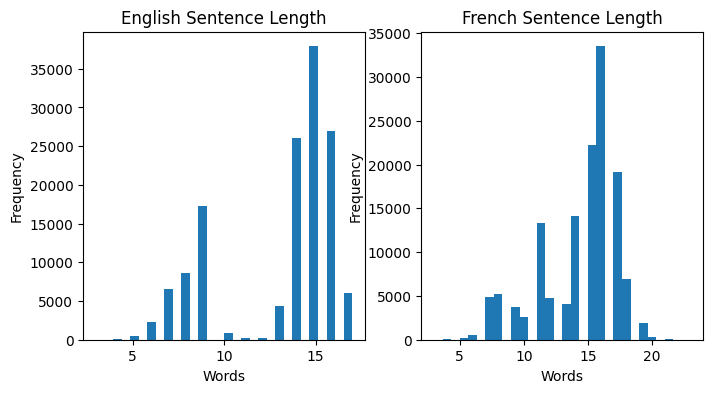

In [14]:
# Histogram for sentences lengths

from matplotlib import figure
import matplotlib.pyplot as plt

figure = plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.hist(df["en_len"], bins=30)
plt.title("English Sentence Length")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(df["fr_len"], bins=30)
plt.title("French Sentence Length")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

In [15]:
df.shape

(137860, 4)

In [16]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Zàâçéèêëîïôûùüÿñæœ\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["english_cleaned"] = df["english"].apply(clean_text)
df["french_cleaned"] = df["french"].apply(clean_text)

In [17]:
# Printing the first cleaned english sentence and it's cleaned translation in french
print(f"English: {df['english_cleaned'][0]}\nFrench: {df['french_cleaned'][0]}")

English: new jersey is sometimes quiet during autumn and it is snowy in april
French: new jersey est parfois calme pendant l automne et il est neigeux en avril


In [18]:
df_cleaned = df[["english_cleaned", "french_cleaned"]]
df_cleaned.head(1)

,english_cleaned,french_cleaned
0,new jersey is sometimes quiet during autumn an...,new jersey est parfois calme pendant l automne...


## **4- Training the model**

In [19]:
from sklearn.model_selection import train_test_split

X = df_cleaned['english_cleaned']
y = df_cleaned['french_cleaned']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((110288,), (27572,), (110288,), (27572,))

In [21]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

eng_tokenizer = Tokenizer()
eng_tokenizer.fit_on_texts(X_train)

fr_tokenizer = Tokenizer()
fr_tokenizer.fit_on_texts(y_train)

In [22]:
eng_seq = eng_tokenizer.texts_to_sequences(X_train)
fr_seq = fr_tokenizer.texts_to_sequences(y_train)

In [23]:
eng_seq = pad_sequences(eng_seq, padding="post")
fr_seq = pad_sequences(fr_seq, padding="post")

In [24]:
eng_vocab = len(eng_tokenizer.word_index) + 1
fr_vocab = len(fr_tokenizer.word_index) + 1

In [25]:
print(f"English vocabulary size: {eng_vocab}")
print(f"French vocabulary size: {fr_vocab}")

English vocabulary size: 200
French vocabulary size: 343


In [26]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Embedding, Dense

embedding_dim = 256
latent_dim = 256

In [27]:
# Encoder

encoder_inputs = Input(shape=(None,))
enc_emb = Embedding(eng_vocab, embedding_dim)(encoder_inputs)

encoder_lstm = LSTM(latent_dim, return_state=True)
encoder_output, state_h, state_c = encoder_lstm(enc_emb)

encoder_states = [state_h, state_c]

# Decoder

decoder_inputs = Input(shape=(None,))
dec_emb = Embedding(fr_vocab, embedding_dim)(decoder_inputs)

decoder_lstm = LSTM(latent_dim, return_sequences=True, return_state=True)
decoder_outputs, _, _ = decoder_lstm(dec_emb, initial_state=encoder_states)

decoder_dense = Dense(fr_vocab, activation="softmax")
decoder_outputs = decoder_dense(decoder_outputs)

In [28]:
# Full Model -> Encoder & Decoder

model = Model([encoder_inputs, decoder_inputs], decoder_outputs)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [29]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, None, 256) │     51,200 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, None, 256) │     87,808 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ [(None, 256),     │    525,312 │ embedding[0][0]   │
│                     │ (None, 256),      │            │                   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, None,     │    525,312 │ embedding_1[0][0… │
│                     │ 256), (None,      │            │ lstm[0][1],       │
│                     │ 256), (None,      │            │ lstm[0][2]        │
│                     │ 256)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, None, 343) │     88,151 │ lstm_1[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,277,783 (4.87 MB)

 Trainable params: 1,277,783 (4.87 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
model.fit(
    [eng_seq, fr_seq],
    fr_seq,
    batch_size=64,
    epochs=10
)

Epoch 1/10
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - accuracy: 0.8867 - loss: 0.6441
Epoch 2/10
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 1.0000 - loss: 7.8479e-04
Epoch 3/10
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 1.0000 - loss: 1.5677e-04
Epoch 4/10
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 1.0000 - loss: 5.4280e-05
Epoch 5/10
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 1.0000 - loss: 2.3891e-05
Epoch 6/10
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 1.0000 - loss: 8.6718e-06
Epoch 7/10
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - accuracy: 1.0000 - loss: 7.7701e-06
Epoch 8/10
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 1.0000 - loss: 2.5210e-06
Epoch 9/10
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 1.0000 - loss: 1.9496e-06
Epoch 10/10
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 1.0000 - loss: 1.2281e-06


In [42]:
import numpy as np

reverse_fr_index = {v: k for k, v in fr_tokenizer.word_index.items()}

def translate_sentence(sentence):

    seq = eng_tokenizer.texts_to_sequences([sentence])
    seq = pad_sequences(seq, maxlen=eng_seq.shape[1], padding="post")

    decoder_input = np.zeros((1, fr_seq.shape[1]))

    prediction = model.predict([seq, decoder_input])

    predicted_tokens = np.argmax(prediction[0], axis=1)

    translated_words = []

    for token in predicted_tokens:
        word = reverse_fr_index.get(token)
        if word:
            translated_words.append(word)

    return " ".join(translated_words)

In [43]:
import numpy as np

tests = [
"I like coffee",
"Who are you?",
"I am a recent graduate",
"May the world be safe",
"I am learning machine learning"
]

for t in tests:
    print("English:", t)
    print("French :", translate_sentence(t))
    print()

English: I like coffee
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
French : 

English: Who are you?
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
French : 

English: I am a recent graduate
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
French : 

English: May the world be safe
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
French : 

English: I am learning machine learning
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
French : 



In [44]:
import numpy as np
import re
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Clean text function
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Zàâçéèêëîïôûùüÿñæœ?.!,\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Translation function
def translate_to_french(sentence, model, eng_tokenizer, fr_tokenizer, max_eng_len, max_fr_len):
    """
    Translates a single English sentence to French using a trained Seq2Seq model.

    Args:
        sentence (str): English sentence.
        model: Trained Seq2Seq Keras model.
        eng_tokenizer: Tokenizer fitted on English sentences.
        fr_tokenizer: Tokenizer fitted on French sentences.
        max_eng_len: Maximum length of English sequences (for padding).
        max_fr_len: Maximum length of French sequences (for padding).

    Returns:
        str: Translated French sentence.
    """

    # 1. Clean the English sentence
    sentence = clean_text(sentence)

    # 2. Convert sentence to sequence of numbers
    seq = eng_tokenizer.texts_to_sequences([sentence])
    seq = pad_sequences(seq, maxlen=max_eng_len, padding="post")

    # 3. Prepare empty decoder input
    decoder_input = np.zeros((1, max_fr_len))

    # 4. Predict probabilities
    prediction = model.predict([seq, decoder_input])

    # 5. Convert predicted indices back to words
    predicted_tokens = np.argmax(prediction[0], axis=1)

    reverse_fr_index = {v: k for k, v in fr_tokenizer.word_index.items()}

    translated_words = []
    for token in predicted_tokens:
        word = reverse_fr_index.get(token)
        if word == "<end>":  # stop at end token
            break
        if word and word != "<start>":
              translated_words.append(woDXlated_words)

In [45]:
tests = [
    "I like coffee",
    "Where is the station",
    "She is my friend",
    "This city is beautiful",
    "I am learning machine learning"
]

for t in tests:
    translation = translate_to_french(t, model, eng_tokenizer, fr_tokenizer, eng_seq.shape[1], fr_seq.shape[1])
    print("English:", t)
    print("French :", translation)
    print()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
English: I like coffee
French : 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
English: Where is the station
French : 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step
English: She is my friend
French : 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
English: This city is beautiful
French : 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
English: I am learning machine learning
French : 

